<a href="https://colab.research.google.com/github/UDAY2232/blood-donation-analytics/blob/main/Blood.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/transfusion.data")

print(df.shape)
print(df.info())
print(df.describe())

(748, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 748 entries, 0 to 747
Data columns (total 5 columns):
 #   Column                                      Non-Null Count  Dtype
---  ------                                      --------------  -----
 0   Recency (months)                            748 non-null    int64
 1   Frequency (times)                           748 non-null    int64
 2   Monetary (c.c. blood)                       748 non-null    int64
 3   Time (months)                               748 non-null    int64
 4   whether he/she donated blood in March 2007  748 non-null    int64
dtypes: int64(5)
memory usage: 29.3 KB
None
       Recency (months)  Frequency (times)  Monetary (c.c. blood)  \
count        748.000000         748.000000             748.000000   
mean           9.506684           5.514706            1378.676471   
std            8.095396           5.839307            1459.826781   
min            0.000000           1.000000             250.000000   
2

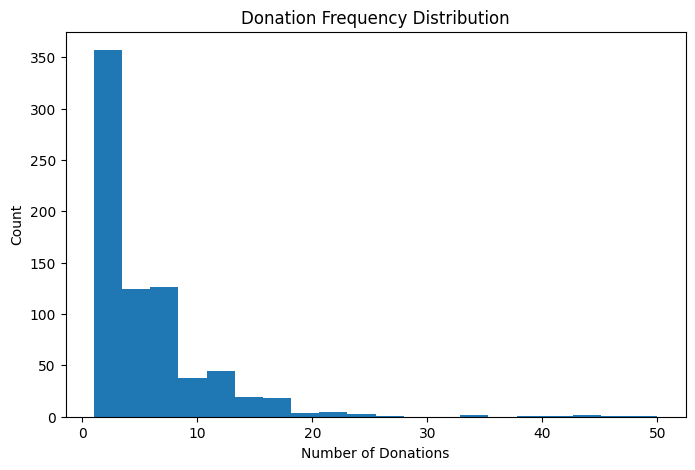

In [3]:
plt.figure(figsize=(8,5))
plt.hist(df["Frequency (times)"], bins=20)
plt.title("Donation Frequency Distribution")
plt.xlabel("Number of Donations")
plt.ylabel("Count")
plt.show()

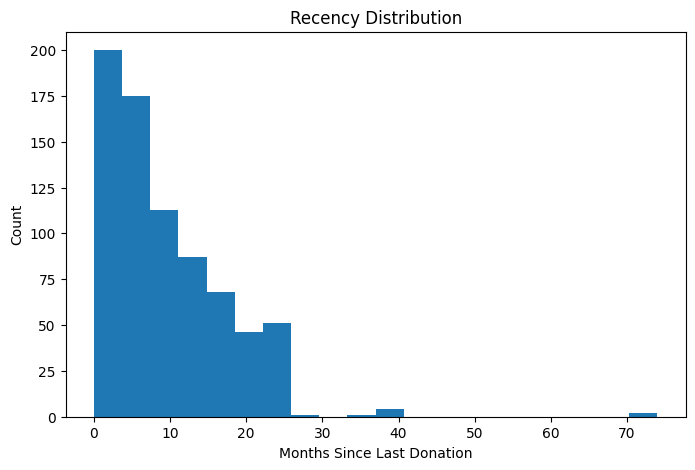

In [4]:
plt.figure(figsize=(8,5))
plt.hist(df["Recency (months)"], bins=20)
plt.title("Recency Distribution")
plt.xlabel("Months Since Last Donation")
plt.ylabel("Count")
plt.show()

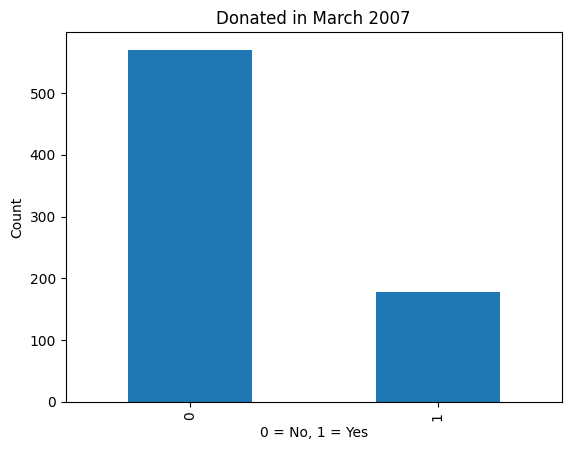

In [5]:
df["whether he/she donated blood in March 2007"].value_counts().plot(kind="bar")

plt.title("Donated in March 2007")
plt.xlabel("0 = No, 1 = Yes")
plt.ylabel("Count")
plt.show()

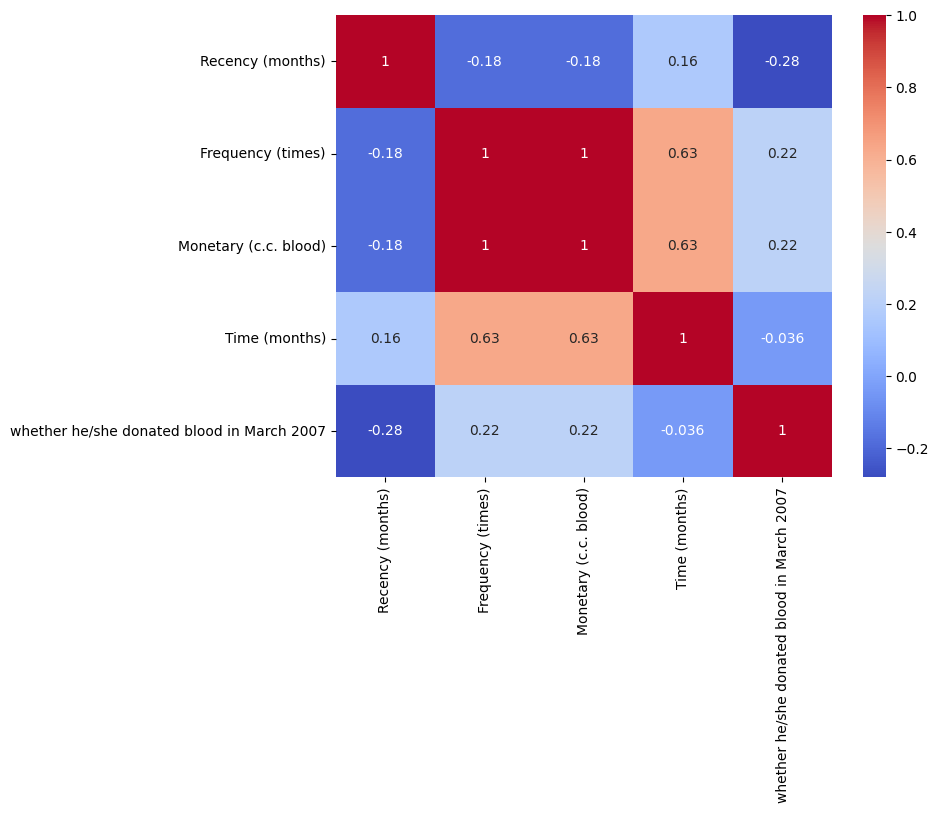

In [6]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(df.corr(),
            annot=True,
            cmap="coolwarm")

plt.show()

In [7]:
def donor_type(row):

    if row["Frequency (times)"] >= 10:
        return "Active"

    elif row["Frequency (times)"] >= 5:
        return "Regular"

    else:
        return "Inactive"

df["Donor_Type"] = df.apply(donor_type, axis=1)

print(df["Donor_Type"].value_counts())

Donor_Type
Inactive    419
Regular     212
Active      117
Name: count, dtype: int64


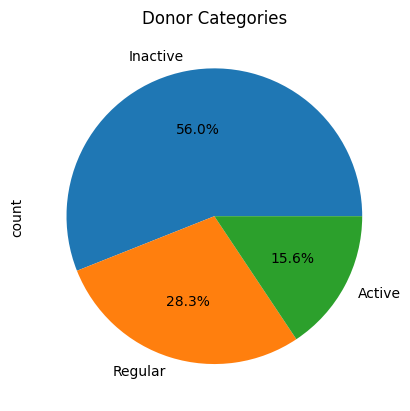

In [8]:
df["Donor_Type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Donor Categories")
plt.show()

In [9]:
import numpy as np

blood_groups = ['O+','B+','A+','AB+','O-','A-','B-','AB-']

probabilities = [0.37,0.32,0.22,0.07,0.01,0.005,0.003,0.002]

df['Blood_Group'] = np.random.choice(
    blood_groups,
    size=len(df),
    p=probabilities
)

In [10]:
cities = [
    'Chennai',
    'Hyderabad',
    'Bangalore',
    'Mumbai',
    'Delhi'
]

df['City'] = np.random.choice(
    cities,
    size=len(df)
)

In [11]:
df['Age'] = np.random.randint(
    18,
    60,
    size=len(df)
)

In [12]:
df['Availability'] = np.where(
    df['Recency (months)'] < 6,
    'Available',
    'Unavailable'
)

In [13]:
df.to_csv(
    "blood_donor_analytics.csv",
    index=False
)

In [14]:
import pandas as pd
import numpy as np

n = 5000

requests = pd.DataFrame({

'Request_ID': range(1,n+1),

'Blood_Group': np.random.choice(
    blood_groups,
    n,
    p=probabilities
),

'City': np.random.choice(
    cities,
    n
),

'Units_Required': np.random.randint(
    1,
    10,
    n
),

'Month': np.random.randint(
    1,
    13,
    n
)

})

requests.to_csv(
    "blood_requests.csv",
    index=False
)

In [15]:
blood_demand = requests.groupby(
    'Blood_Group'
)['Units_Required'].sum()

print(blood_demand)

Blood_Group
A+     5559
A-      128
AB+    1813
AB-      85
B+     7926
B-       73
O+     9431
O-      310
Name: Units_Required, dtype: int64


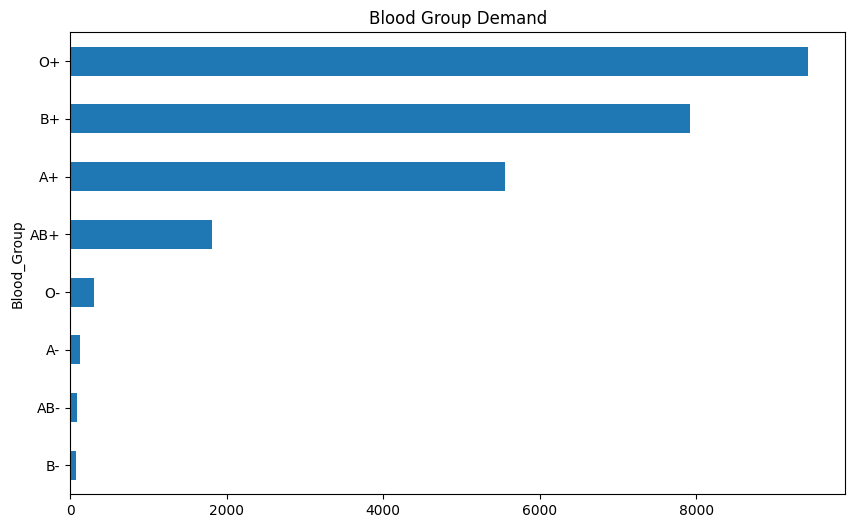

In [16]:
blood_demand.sort_values().plot(
    kind='barh',
    figsize=(10,6)
)

plt.title("Blood Group Demand")
plt.show()

In [17]:
blood_supply = df.groupby(
    'Blood_Group'
)['Frequency (times)'].sum()

print(blood_supply)

Blood_Group
A+      800
A-        7
AB+     290
B+     1394
B-       36
O+     1567
O-       31
Name: Frequency (times), dtype: int64


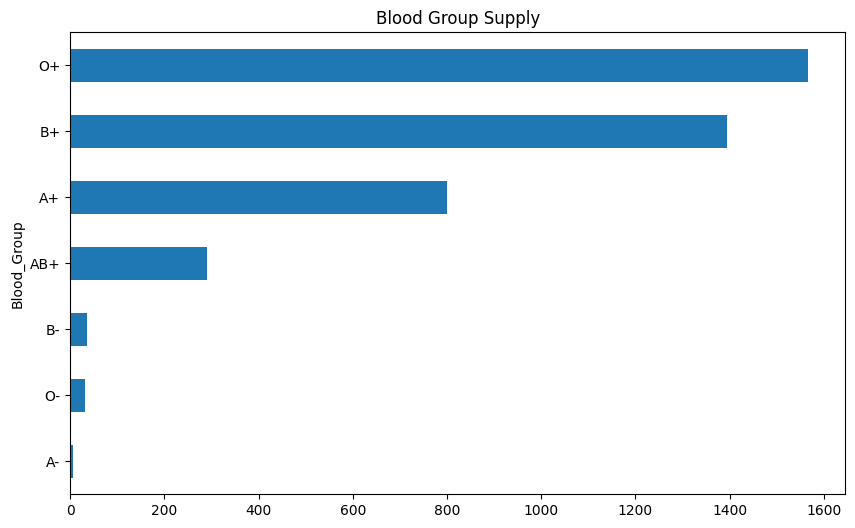

In [18]:
blood_supply.sort_values().plot(
    kind='barh',
    figsize=(10,6)
)

plt.title("Blood Group Supply")
plt.show()

In [19]:
comparison = pd.DataFrame({
    'Demand': blood_demand,
    'Supply': blood_supply
})

comparison['Gap'] = (
    comparison['Supply']
    - comparison['Demand']
)

print(comparison)

             Demand  Supply     Gap
Blood_Group                        
A+             5559   800.0 -4759.0
A-              128     7.0  -121.0
AB+            1813   290.0 -1523.0
AB-              85     NaN     NaN
B+             7926  1394.0 -6532.0
B-               73    36.0   -37.0
O+             9431  1567.0 -7864.0
O-              310    31.0  -279.0


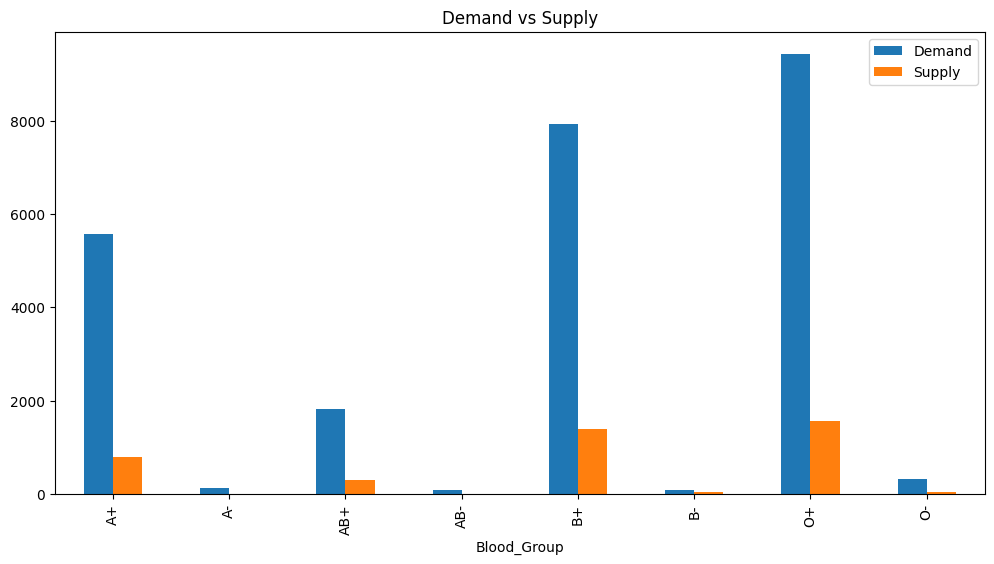

In [20]:
comparison[['Demand','Supply']].plot(
    kind='bar',
    figsize=(12,6)
)

plt.title("Demand vs Supply")
plt.show()

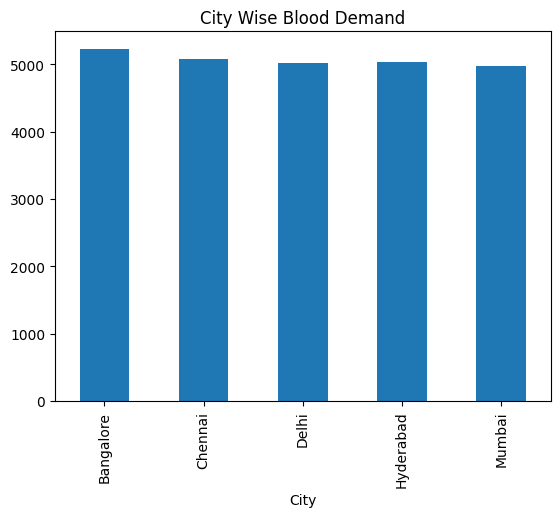

In [21]:
city_demand = requests.groupby(
    'City'
)['Units_Required'].sum()

city_demand.plot(
    kind='bar'
)

plt.title("City Wise Blood Demand")
plt.show()

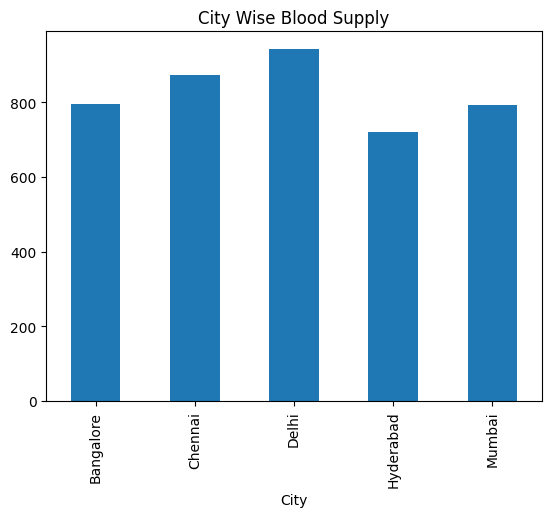

In [22]:
city_supply = df.groupby(
    'City'
)['Frequency (times)'].sum()

city_supply.plot(
    kind='bar'
)

plt.title("City Wise Blood Supply")
plt.show()

In [23]:
city_compare = pd.DataFrame({
    'Demand': city_demand,
    'Supply': city_supply
})

city_compare['Gap'] = (
    city_compare['Supply']
    - city_compare['Demand']
)

city_compare.sort_values(
    'Gap'
)

,Demand,Supply,Gap
City,,,
Bangalore,5228,796,-4432
Hyderabad,5035,720,-4315
Chennai,5072,873,-4199
Mumbai,4972,793,-4179
Delhi,5018,943,-4075


In [24]:
conditions = [
    df['Frequency (times)'] < 5,
    (df['Frequency (times)'] >= 5) & (df['Frequency (times)'] < 15),
    df['Frequency (times)'] >= 15
]

choices = [
    'Inactive',
    'Regular',
    'Super Donor'
]

# Added default parameter to match the string type of choices
df['Segment'] = np.select(
    conditions,
    choices,
    default='Unknown'
)

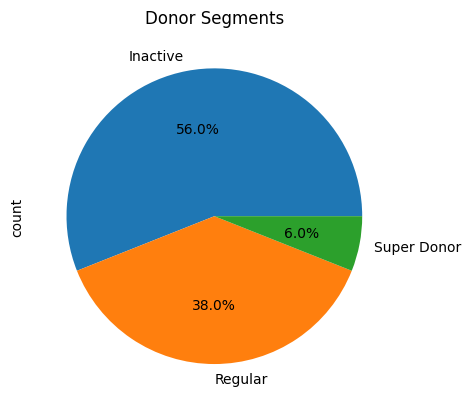

In [25]:
df['Segment'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Donor Segments")
plt.show()

In [26]:
total_donors = len(df)

active_donors = len(
    df[
        df['Availability']
        ==
        'Available'
    ]
)

total_requests = len(requests)

total_units = requests[
    'Units_Required'
].sum()

In [27]:
monthly_demand = requests.groupby(
    ['Month','Blood_Group']
)['Units_Required'].sum().reset_index()

In [28]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

monthly_demand['Blood_Group'] = le.fit_transform(
    monthly_demand['Blood_Group']
)

In [29]:
X = monthly_demand[
    ['Month','Blood_Group']
]

y = monthly_demand[
    'Units_Required'
]

In [30]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [31]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()

model.fit(
    X_train,
    y_train
)

RandomForestRegressor()

In [32]:
predictions = model.predict(
    X_test
)

In [33]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(
    y_test,
    predictions
)

print(mae)

54.10277777777779


In [34]:
future = pd.DataFrame({

'Month':[13],

'Blood_Group':[
    le.transform(['O+'])[0]
]

})

prediction = model.predict(
    future
)

print(prediction)

[778.06]


In [35]:
eligible = df[
    df['Blood_Group'] == 'O+'
]

In [36]:
eligible = eligible[
    eligible['Availability']
    ==
    'Available'
]

In [37]:
eligible = eligible[
    eligible['Recency (months)']
    > 3
]

In [38]:
eligible = eligible.sort_values(
    by='Frequency (times)',
    ascending=False
)

In [39]:
print(eligible)

     Recency (months)  Frequency (times)  Monetary (c.c. blood)  \
9                   5                 46                  11500   
44                  4                 20                   5000   
55                  4                 19                   4750   
562                 4                 16                   4000   
25                  4                 14                   3500   
..                ...                ...                    ...   
219                 4                  1                    250   
221                 4                  1                    250   
610                 4                  1                    250   
614                 4                  1                    250   
618                 4                  1                    250   

     Time (months)  whether he/she donated blood in March 2007 Donor_Type  \
9               98                                           1     Active   
44              69                       

In [40]:
eligible.tail(10)

,Recency (months),Frequency (times),Monetary (c.c. blood),Time (months),whether he/she donated blood in March 2007,Donor_Type,Blood_Group,City,Age,Availability,Segment
225,4,1,250,4,1,Inactive,O+,Hyderabad,22,Available,Inactive
226,4,1,250,4,0,Inactive,O+,Delhi,20,Available,Inactive
214,4,1,250,4,0,Inactive,O+,Bangalore,27,Available,Inactive
215,4,1,250,4,1,Inactive,O+,Mumbai,20,Available,Inactive
216,4,1,250,4,0,Inactive,O+,Delhi,39,Available,Inactive
219,4,1,250,4,0,Inactive,O+,Bangalore,35,Available,Inactive
221,4,1,250,4,1,Inactive,O+,Chennai,50,Available,Inactive
610,4,1,250,4,0,Inactive,O+,Hyderabad,25,Available,Inactive
614,4,1,250,4,0,Inactive,O+,Delhi,30,Available,Inactive
618,4,1,250,4,1,Inactive,O+,Delhi,30,Available,Inactive


In [41]:
comparison['Risk_Score'] = (
    comparison['Demand'] /
    comparison['Supply']
)

comparison.sort_values(
    'Risk_Score',
    ascending=False
)

,Demand,Supply,Gap,Risk_Score
Blood_Group,,,,
A-,128,7.0,-121.0,18.285714
O-,310,31.0,-279.0,10.000000
A+,5559,800.0,-4759.0,6.948750
AB+,1813,290.0,-1523.0,6.251724
O+,9431,1567.0,-7864.0,6.018507
B+,7926,1394.0,-6532.0,5.685796
B-,73,36.0,-37.0,2.027778
AB-,85,NaN,NaN,NaN
